In [1]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import pandas as pd
from pprint import pprint

from arxiv_paper_discovery.config import PROCESSED_DATA_DIR
from arxiv_paper_discovery.utils import compute_label_coverage

%load_ext autoreload
%autoreload 2


/home/dhiran/miniconda3/envs/arxiv-paper-discovery/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
arxiv_taxonomy_dataset = load_from_disk(PROCESSED_DATA_DIR / "arxiv_taxonomy_dataset")
print(arxiv_taxonomy_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date', 'labels'],
        num_rows: 2384152
    })
    val: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date', 'labels'],
        num_rows: 298019
    })
    test: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date', 'labels'],
        num_rows: 298019
    })
})


### Label Distribution

In [3]:
counter = Counter()

for labels in tqdm(arxiv_taxonomy_dataset["test"]["labels"], desc="Counting labels"):
    counter.update(labels)

label_df = pd.DataFrame(counter.items(), columns=["label", "count"])
label_df = label_df.sort_values(by="count", ascending=False).reset_index(drop=True)
label_df.to_csv("../outputs/analysis/test_taxonomy_label_distribution.csv", index=False)

Counting labels: 100%|██████████| 298019/298019 [00:02<00:00, 105616.97it/s]


### Jensen-Shannon Divergence

Treats each split's label distribution as a probability vector and measures how far they are from each
other. Result is between 0 (identical) and 1 (completely different). Directly interpretable.


In [4]:
from scipy.spatial.distance import jensenshannon
import numpy as np

train_df = pd.read_csv("../outputs/analysis/train_taxonomy_label_distribution.csv")
val_df   = pd.read_csv("../outputs/analysis/val_taxonomy_label_distribution.csv")
test_df  = pd.read_csv("../outputs/analysis/test_taxonomy_label_distribution.csv")

labels = sorted(train_df["label"].tolist())

train_probs = train_df.set_index("label").reindex(labels)["count"].values.astype(float)
val_probs   = val_df.set_index("label").reindex(labels)["count"].values.astype(float)
test_probs  = test_df.set_index("label").reindex(labels)["count"].values.astype(float)

train_probs /= train_probs.sum()
val_probs   /= val_probs.sum()
test_probs  /= test_probs.sum()

print(f"JS divergence train<->val:  {jensenshannon(train_probs, val_probs):.6f}")
print(f"JS divergence train<->test: {jensenshannon(train_probs, test_probs):.6f}")
print(f"JS divergence val<->test:   {jensenshannon(val_probs, test_probs):.6f}")

JS divergence train<->val:  0.002908
JS divergence train<->test: 0.003381
JS divergence val<->test:   0.004054


### Stats for labels per paper

In [5]:
num_labels_per_paper = [
    len(item["labels"]) 
    for item in tqdm(arxiv_taxonomy_dataset["train"], desc="Counting labels per paper")
]

print("\nStats for labels per paper:")
print(f"Average: {np.mean(num_labels_per_paper):.2f}")
print(f"Max: {np.max(num_labels_per_paper)}")
print(f"Min: {np.min(num_labels_per_paper)}")

Counting labels per paper:   0%|          | 0/2384152 [00:00<?, ?it/s]

Counting labels per paper: 100%|██████████| 2384152/2384152 [01:25<00:00, 27805.03it/s]



Stats for labels per paper:
Average: 1.40
Max: 9
Min: 1


### Cumulative Coverage Curve

In [4]:
coverage, labels = compute_label_coverage(arxiv_taxonomy_dataset["train"], column="labels")

Counting labels:   0%|          | 0/2384152 [00:00<?, ?it/s]

Computing coverage: 100%|██████████| 25/25 [00:02<00:00, 11.01it/s]


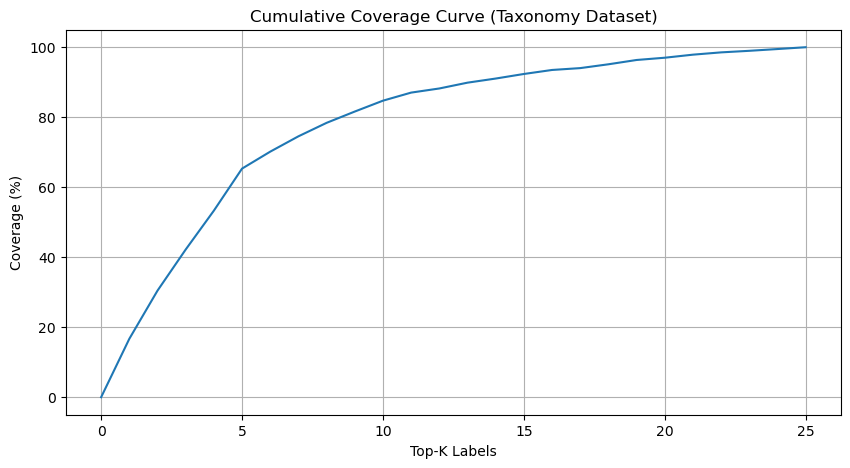

In [ ]:
plt.figure(figsize=(10, 5))
coverage_plot = [0] + coverage
x = range(len(coverage_plot))

plt.plot(x, coverage_plot)
plt.xlabel("Top-K Labels")
plt.ylabel("Coverage (%)")
plt.title("Cumulative Coverage Curve (Taxonomy Dataset)")
plt.grid()

plt.savefig("../outputs/plots/taxonomy_cumulative_coverage_curve.png", dpi=300)
plt.show()

### Manual JSON Creation for prediction

In [9]:
import random
import json

def sample_papers(dataset, batch_size=5):
    indices = random.sample(range(len(dataset)), batch_size)
    papers = [{"title": dataset[i]["title"], "abstract": dataset[i]["abstract"]} for i in indices]
    print(json.dumps(papers, indent=2))

sample_papers(arxiv_taxonomy_dataset["test"], batch_size=10)


[
  {
    "title": "Implementation of Logical Functions in the Game of Life",
    "abstract": "The Game of Life cellular automaton is a classical example of a massively parallel collision-based computing device. The automaton exhibits mobile patterns, gliders, and generators of the mobile patterns, glider guns, in its evolution. We show how to construct the basic logical operations, AND, OR, NOT in space-time configurations of the cellular automaton. Also decomposition of complicated Boolean functions is discussed. Advantages of our technique are demonstrated on an example of binary adder, realized via collision of glider streams."
  },
  {
    "title": "$A_{FB}$ as a discovery tool for $Z^\\prime$ bosons at the LHC",
    "abstract": "The Forward-Backward Asymmetry (AFB) in $Z^\\prime$ physics is commonly only perceived as the observable which possibly allows one to interpret a $Z^\\prime$ signal by distinguishing different models of such (heavy) spin-1 bosons. In this article, we exam